# Analisis Dataset Log Akses Web (Trafik Bersih Tanpa Cyber Attack)
Notebook ini memproses log akses web `dataset/logfiles.log`, menerapkan filter untuk mengeliminasi trafik serangan siber (cyber attack) secara proaktif, mengagregasikan Requests Per Second (RPS) tingkat detik, serta memvisualisasikan data trafik bersih.

Langkah pembersihan meliputi:
1. Hanya mengizinkan HTTP method `GET` dan `POST`.
2. Hanya mengizinkan HTTP status code sukses `200`, `302`, dan `304`.
3. Mengeliminasi request ke endpoint administratif (seperti `/usr/admin`, `/usr/admin/developer`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from datetime import datetime

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12


In [2]:
log_file_path = 'dataset/logfiles.log'

print("Membaca dan mem-parsing log file secara efisien dengan filter anti-cyberattack...")
start_time = time.time()
data = []

# Kriteria filter trafik bersih
allowed_methods = {'GET', 'POST'}
allowed_statuses = {200, 302, 304}

with open(log_file_path, 'r', encoding='latin1') as f:
    for i, line in enumerate(f):
        try:
            parts = line.split('"')
            
            # Cek status code terlebih dahulu untuk eliminasi cepat
            status_size_parts = parts[2].strip().split()
            status = int(status_size_parts[0])
            if status not in allowed_statuses:
                continue
                
            req_parts = parts[1].split()
            method = req_parts[0]
            if method not in allowed_methods:
                continue
                
            endpoint = req_parts[1]
            if 'admin' in endpoint:
                continue
                
            ts_start = parts[0].find('[') + 1
            ts_end = parts[0].find(']')
            ts_str = parts[0][ts_start:ts_end-6] # Potong '+0530'
            dt = datetime.strptime(ts_str, '%d/%b/%Y:%H:%M:%S')
            
            size = int(status_size_parts[1])
            latency = int(parts[-1].strip())
            
            data.append((dt, method, endpoint, status, size, latency))
        except Exception:
            continue
        if (i + 1) % 200000 == 0:
            print(f"Selesai memproses {i + 1} baris...")

df = pd.DataFrame(data, columns=['datetime', 'method', 'endpoint', 'status', 'size_bytes', 'latency_ms'])
df['method'] = df['method'].astype('category')
df['endpoint'] = df['endpoint'].astype('category')
df['status'] = df['status'].astype('uint16')
df['size_bytes'] = df['size_bytes'].astype('uint32')
df['latency_ms'] = df['latency_ms'].astype('uint32')

df.set_index('datetime', inplace=True)
df.sort_index(inplace=True)

print(f"Total baris log bersih: {len(df)} (diproses dalam {time.time() - start_time:.2f} detik)")
df.head()


Membaca dan mem-parsing log file secara efisien dengan filter anti-cyberattack...


Selesai memproses 1000000 baris...


Total baris log bersih: 165591 (diproses dalam 5.97 detik)


,method,endpoint,status,size_bytes,latency_ms
datetime,,,,,
2017-04-07 00:00:00,POST,/usr/login,200,4810,2971
2017-04-07 00:00:00,POST,/usr/login,200,4810,2040
2017-04-07 00:00:00,GET,/usr/login,304,5011,4244
2017-04-07 00:00:02,POST,/usr/login,304,4824,3096
2017-04-07 00:00:02,POST,/usr/login,200,5160,3460


In [3]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 165591 entries, 2017-04-07 00:00:00 to 2017-04-08 00:00:00
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype   
---  ------      --------------   -----   
 0   method      165591 non-null  category
 1   endpoint    165591 non-null  category
 2   status      165591 non-null  uint16  
 3   size_bytes  165591 non-null  uint32  
 4   latency_ms  165591 non-null  uint32  
dtypes: category(2), uint16(1), uint32(2)
memory usage: 3.2 MB


Distribusi endpoint bersih:
endpoint
/usr/login            49848
/usr                  49188
/usr/register         49124
/                     17338
/scan/attack1/a100        1
                      ...  
/scan/attack3/a91         1
/scan/attack3/a93         1
/scan/attack3/a95         1
/scan/attack3/a97         1
/scan/attack3/a99         1
Name: count, Length: 97, dtype: int64


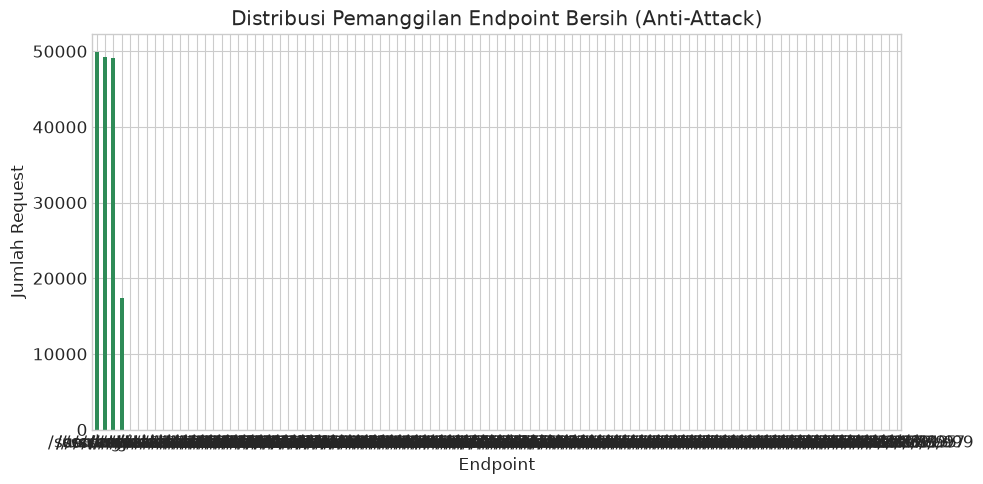

In [4]:
endpoint_counts = df['endpoint'].value_counts()
print("Distribusi endpoint bersih:")
print(endpoint_counts)

plt.figure(figsize=(10, 5))
endpoint_counts.plot(kind='bar', color='seagreen')
plt.title('Distribusi Pemanggilan Endpoint Bersih (Anti-Attack)')
plt.xlabel('Endpoint')
plt.ylabel('Jumlah Request')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Distribusi HTTP Status Code Bersih:
status
200    91933
304    73615
302       43
Name: count, dtype: int64


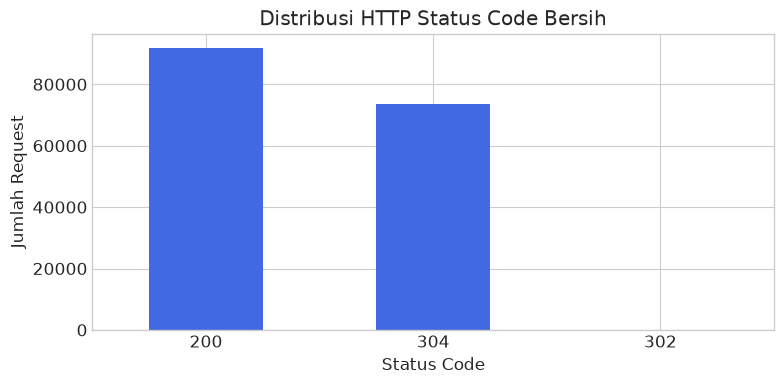

In [5]:
status_counts = df['status'].value_counts()
print("Distribusi HTTP Status Code Bersih:")
print(status_counts)

plt.figure(figsize=(8, 4))
status_counts.plot(kind='bar', color='royalblue')
plt.title('Distribusi HTTP Status Code Bersih')
plt.xlabel('Status Code')
plt.ylabel('Jumlah Request')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [6]:
# Resample ke 1 detik untuk menghitung total RPS
print("Menghitung total RPS per detik...")
total_rps = df.resample('1s').size()

# Hitung RPS untuk masing-masing endpoint bersih (Top 4 + 'Others')
print("Menghitung RPS per-endpoint...")
top_endpoints = ['/usr/login', '/usr', '/usr/register', '/']
plot_cols = top_endpoints + ['Others']

rps_endpoints = {}
for ep in top_endpoints:
    ep_df = df[df['endpoint'] == ep]
    rps_endpoints[ep] = ep_df.resample('1s').size().reindex(total_rps.index, fill_value=0)

# Sisanya dikelompokkan ke 'Others'
others_df = df[~df['endpoint'].isin(top_endpoints)]
rps_endpoints['Others'] = others_df.resample('1s').size().reindex(total_rps.index, fill_value=0)

# Gabungkan ke satu DataFrame
rps_df = pd.DataFrame(rps_endpoints)
rps_df['total_rps'] = total_rps
rps_df.head()


Menghitung total RPS per detik...


Menghitung RPS per-endpoint...


,/usr/login,/usr,/usr/register,/,Others,total_rps
datetime,,,,,,
2017-04-07 00:00:00,3,0,0,0,0,3
2017-04-07 00:00:01,0,0,0,0,0,0
2017-04-07 00:00:02,2,0,0,0,0,2
2017-04-07 00:00:03,2,0,0,0,0,2
2017-04-07 00:00:04,0,1,0,0,0,1


In [7]:
# Statistik Deskriptif RPS
stats = rps_df.describe()
print("Statistik Deskriptif RPS per-detik (Trafik Bersih):")
print(stats.loc[['min', 'mean', 'max']])


Statistik Deskriptif RPS per-detik (Trafik Bersih):
      /usr/login      /usr  /usr/register            /     Others   total_rps
min     0.000000  0.000000       0.000000     0.000000   0.000000     0.00000
mean    0.576938  0.569299       0.568558     0.200669   0.001076     1.91654
max    33.000000  6.000000       6.000000  9396.000000  49.000000  9396.00000


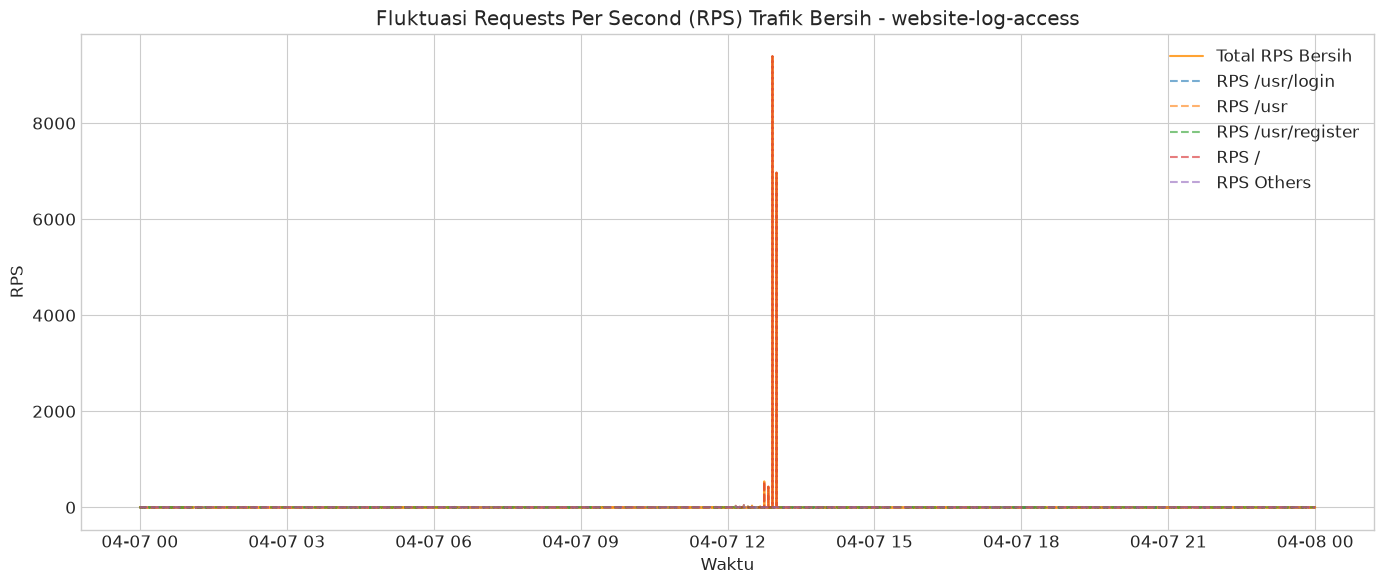

In [8]:
# Plot total RPS dari waktu ke waktu
plt.figure(figsize=(14, 6))
plt.plot(rps_df.index, rps_df['total_rps'], label='Total RPS Bersih', color='darkorange', alpha=0.8)
for ep in plot_cols:
    plt.plot(rps_df.index, rps_df[ep], label=f'RPS {ep}', alpha=0.6, linestyle='--')

plt.title('Fluktuasi Requests Per Second (RPS) Trafik Bersih - website-log-access')
plt.xlabel('Waktu')
plt.ylabel('RPS')
plt.legend()
plt.tight_layout()
plt.show()


Trafik puncak bersih terjadi pada: 2017-04-07 12:55:00 dengan 9396 RPS


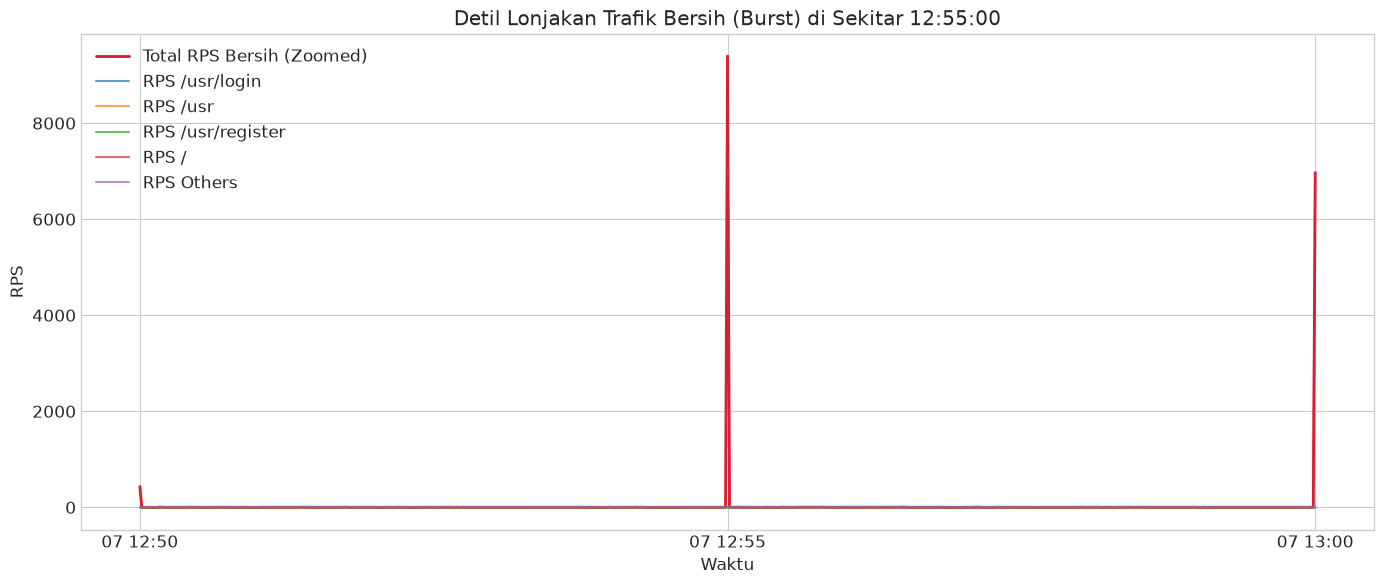

In [9]:
# Cari timestamp di mana terjadi lonjakan (peak)
peak_time = rps_df['total_rps'].idxmax()
print(f"Trafik puncak bersih terjadi pada: {peak_time} dengan {rps_df['total_rps'].max()} RPS")

# Zoom ke area sekitar peak (+/- 5 menit)
zoom_start = peak_time - pd.Timedelta(minutes=5)
zoom_end = peak_time + pd.Timedelta(minutes=5)
zoomed_df = rps_df.loc[zoom_start:zoom_end]

plt.figure(figsize=(14, 6))
plt.plot(zoomed_df.index, zoomed_df['total_rps'], label='Total RPS Bersih (Zoomed)', color='crimson', linewidth=2)
for ep in plot_cols:
    plt.plot(zoomed_df.index, zoomed_df[ep], label=f'RPS {ep}', alpha=0.7)

plt.title(f'Detil Lonjakan Trafik Bersih (Burst) di Sekitar {peak_time:%H:%M:%S}')
plt.xlabel('Waktu')
plt.ylabel('RPS')
plt.legend()
plt.tight_layout()
plt.show()


In [10]:
# Simpan hasil agregasi per-detik ke CSV
output_csv_path = 'dataset/aggregated_clean_log_rps.csv'
rps_df.to_csv(output_csv_path)
print(f"Dataset hasil agregasi per-detik bersih berhasil disimpan ke: {output_csv_path}")


Dataset hasil agregasi per-detik bersih berhasil disimpan ke: dataset/aggregated_clean_log_rps.csv


## Kesimpulan & Formulasi Skenario Pengujian
Setelah membuang rute cyber attack (seperti request bermetode berbahaya, status code error 404/500, dan endpoint admin), trafik yang tersisa mewakili pola interaksi pengguna normal. Skenario autoscaling dapat didesain berdasarkan profil trafik bersih ini.